# 统一评估结果分析

加载所有 ML + DL 模型的 `eval_results.json`，对比验证集（weekly）和滑动验证集（sliding）的 final_score 等指标。

In [1]:
import os, json, warnings
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

## 加载评估结果

In [3]:
RESULTS_FILE = "../output/eval_all_results.json"

if os.path.exists(RESULTS_FILE):
    df = pd.read_json(RESULTS_FILE, orient='records')
    print(f"Loaded {len(df)} experiments from {RESULTS_FILE}")
    if 'kind' in df.columns:
        print(f"  DL: {len(df[df['kind']=='dl'])}  ML: {len(df[df['kind']=='ml'])}")
else:
    import glob
    files = glob.glob("../model/**/eval_results.json", recursive=True)
    rows = []
    for f in files:
        with open(f) as fh:
            r = json.load(fh)
            r['exp_dir'] = str(Path(f).parent)
            rows.append(r)
    df = pd.DataFrame(rows) if rows else pd.DataFrame()
    print(f"Loaded {len(df)} experiments from individual eval_results.json")

display_cols = ['model_type', 'kind', 'weekly_score', 'sliding_score',
                'weekly_rank_ic', 'sliding_rank_ic',
                'weekly_ndcg', 'sliding_ndcg', 'weekly_hit_rate', 'sliding_hit_rate']
display_cols = [c for c in display_cols if c in df.columns]
if not df.empty:
    display(df[display_cols].sample(10))

Loaded 435 experiments from ../output/eval_all_results.json
  DL: 433  ML: 2


,model_type,kind,weekly_score,sliding_score,weekly_rank_ic,sliding_rank_ic,weekly_ndcg,sliding_ndcg,weekly_hit_rate,sliding_hit_rate
163,mamba,dl,0.115512,0.067126,0.021800,0.046525,0.045123,-0.119603,0.041667,0.053030
42,dlinear,dl,0.010110,0.114039,-0.179884,0.002319,-0.115415,-0.076938,0.083333,0.128788
321,patchtst,dl,0.103936,0.186643,-0.024828,-0.022313,0.134514,0.076993,0.083333,0.181818
427,timesnet,dl,0.160106,0.228302,-0.017955,0.015017,0.116329,0.096246,0.083333,0.174242
361,timesnet,dl,0.135000,0.159276,-0.008113,-0.000300,0.103900,-0.058601,0.125000,0.159091
409,timesnet,dl,0.020793,0.008853,-0.007850,0.046138,-0.062817,-0.192358,0.000000,0.015152
10,dlinear,dl,-0.054892,0.137836,0.044701,0.022459,-0.205367,-0.058794,0.041667,0.121212
359,timesnet,dl,0.137649,0.204034,-0.007441,0.012411,0.156262,0.087356,0.125000,0.174242
136,nlinear,dl,0.138496,0.171324,0.097566,0.038847,-0.000948,-0.044097,0.041667,0.128788
35,dlinear,dl,-0.118560,0.106020,0.004895,0.055058,-0.242829,-0.069471,0.041667,0.098485


## 验证指标相关性

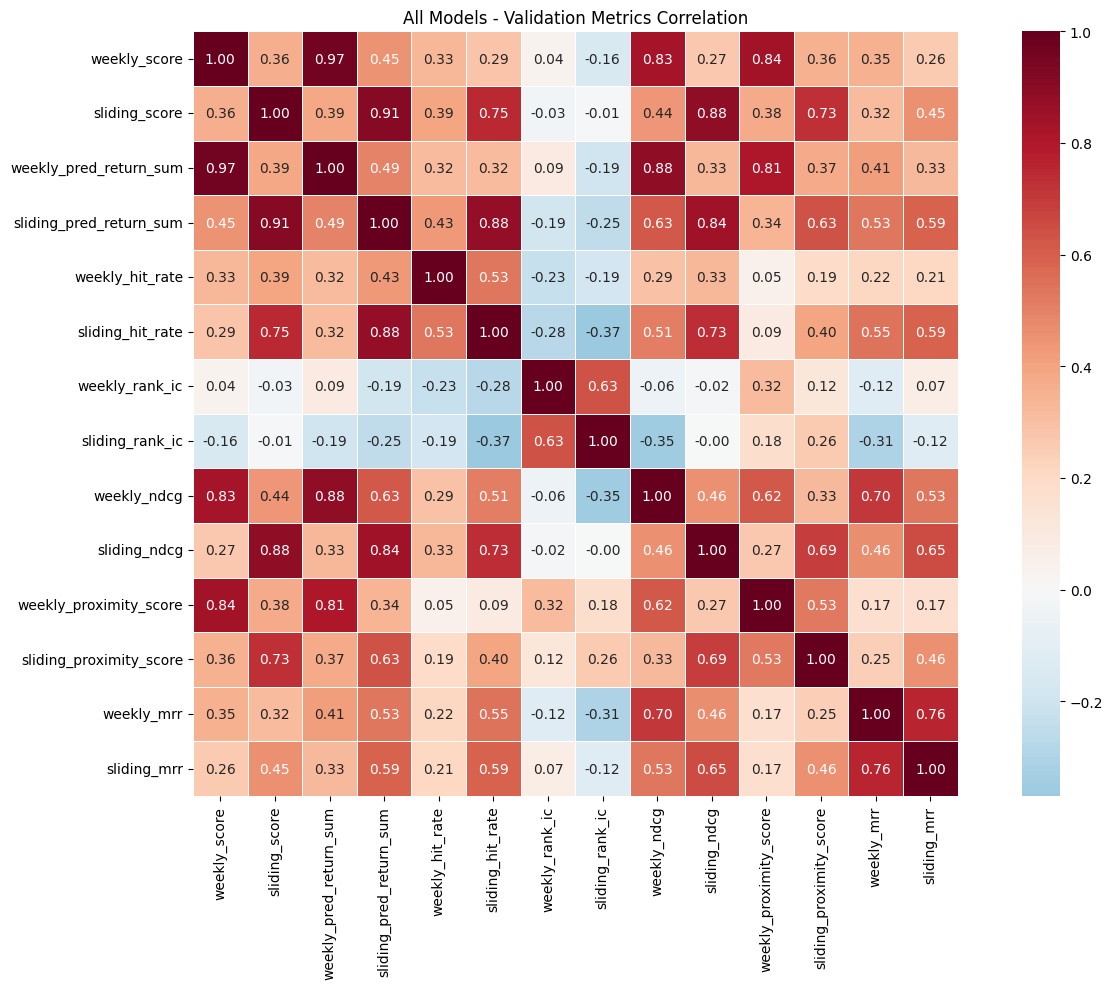

In [4]:
if not df.empty:
    score_cols = ['weekly_score', 'sliding_score', 'weekly_pred_return_sum',
                  'sliding_pred_return_sum', 'weekly_hit_rate', 'sliding_hit_rate',
                  'weekly_rank_ic', 'sliding_rank_ic', 'weekly_ndcg', 'sliding_ndcg',
                  'weekly_proximity_score', 'sliding_proximity_score',
                  'weekly_mrr', 'sliding_mrr']
    score_cols = [c for c in score_cols if c in df.columns]
    corr = df[score_cols].corr()
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5)
    plt.title('All Models - Validation Metrics Correlation')
    plt.tight_layout()
    plt.show()

## 各指标 Top 10

In [5]:
if not df.empty:
    metrics = ['weekly_score', 'sliding_score', 'weekly_pred_return_sum',
               'sliding_pred_return_sum', 'weekly_rank_ic', 'sliding_rank_ic',
               'weekly_ndcg', 'sliding_ndcg', 'weekly_hit_rate', 'sliding_hit_rate']
    metrics = [m for m in metrics if m in df.columns]
    for m in metrics:
        top = df.nlargest(min(10, len(df)), m)
        print(f'\nTop 10 by {m}:')
        top['short_dir'] = top['exp_dir'].apply(lambda x: '/'.join(x.split('/')[-3:-1]) if '/' in x else x)
        display(top[['model_type', 'kind', 'short_dir', m]].reset_index(drop=True))


Top 10 by weekly_score:


,model_type,kind,short_dir,weekly_score
0,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.253435
1,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.225811
2,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.225811
3,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.221507
4,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.220853
5,dlinear,dl,model/bayes_dlinear_74_3_2026-01-01_2026-03-31,0.219474
6,mamba,dl,model/bayes_mamba_74_3_2026-01-01_2026-03-31,0.215744
7,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.213905
8,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.213765
9,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.211291



Top 10 by sliding_score:


,model_type,kind,short_dir,sliding_score
0,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.331848
1,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.330155
2,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.325181
3,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.323164
4,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.322652
5,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.319674
6,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.313080
7,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.310795
8,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.310012
9,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.309617



Top 10 by weekly_pred_return_sum:


...

,model_type,kind,short_dir,sliding_ndcg
0,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.181445
1,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.181419
2,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.166703
3,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.166398
4,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.164123
5,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.164055
6,patchtst,dl,model/bayes_patchtst_74_3_2026-01-01_2026-03-31,0.159960
7,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.158582
8,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.156277
9,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.153281



Top 10 by weekly_hit_rate:


,model_type,kind,short_dir,weekly_hit_rate
0,xgb,ml,../model,0.172619
1,dlinear,dl,model/bayes_dlinear_74_3_2026-01-01_2026-03-31,0.166667
2,dlinear,dl,model/bayes_dlinear_74_3_2026-01-01_2026-03-31,0.166667
3,dlinear,dl,model/bayes_dlinear_74_3_2026-01-01_2026-03-31,0.166667
4,dlinear,dl,model/bayes_dlinear_74_3_2026-01-01_2026-03-31,0.166667
5,dlinear,dl,model/bayes_dlinear_74_3_2026-01-01_2026-03-31,0.166667
6,nlinear,dl,model/bayes_nlinear_74_3_2026-01-01_2026-03-31,0.166667
7,nlinear,dl,model/bayes_nlinear_74_3_2026-01-01_2026-03-31,0.166667
8,itransformer,dl,model/bayes_itransformer_74_3_2026-01-01_2026-...,0.166667
9,itransformer,dl,model/bayes_itransformer_74_3_2026-01-01_2026-...,0.166667



Top 10 by sliding_hit_rate:


,model_type,kind,short_dir,sliding_hit_rate
0,patchtst,dl,model/bayes_patchtst_74_3_2026-01-01_2026-03-31,0.242424
1,patchtst,dl,model/bayes_patchtst_74_3_2026-01-01_2026-03-31,0.242424
2,patchtst,dl,model/bayes_patchtst_74_3_2026-01-01_2026-03-31,0.242424
3,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.242424
4,patchtst,dl,model/bayes_patchtst_74_3_2026-01-01_2026-03-31,0.234848
5,patchtst,dl,model/bayes_patchtst_74_3_2026-01-01_2026-03-31,0.234848
6,patchtst,dl,model/bayes_patchtst_74_3_2026-01-01_2026-03-31,0.234848
7,patchtst,dl,model/bayes_patchtst_74_3_2026-01-01_2026-03-31,0.234848
8,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.234848
9,timesnet,dl,model/bayes_timesnet_74_3_2026-01-01_2026-03-31,0.234848


## 各模型类型统计

In [6]:
if not df.empty:
    summary = df.groupby('model_type').agg(
        count=('sliding_score', 'count'),
        mean_sliding=('sliding_score', 'mean'),
        max_sliding=('sliding_score', 'max'),
        mean_weekly=('weekly_score', 'mean'),
        max_weekly=('weekly_score', 'max'),
        mean_rank_ic=('sliding_rank_ic', 'mean'),
        mean_ndcg=('sliding_ndcg', 'mean'),
        mean_hit_rate=('sliding_hit_rate', 'mean'),
    ).round(4).sort_values('max_sliding', ascending=False)
    print("Per-model-type summary (sorted by max sliding_score):")
    display(summary)

    # Best overall
    best = df.loc[df['sliding_score'].idxmax()]
    print(f"\nBest overall: {best['model_type']} ({best.get('kind', '?')})")
    print(f"  sliding_score={best['sliding_score']:.4f}  weekly_score={best['weekly_score']:.4f}")
    print(f"  rank_ic={best.get('sliding_rank_ic', 0):.4f}  ndcg={best.get('sliding_ndcg', 0):.4f}")
    print(f"  dir: {best.get('exp_dir', '?')}")

Per-model-type summary (sorted by max sliding_score):


,count,mean_sliding,max_sliding,mean_weekly,max_weekly,mean_rank_ic,mean_ndcg,mean_hit_rate
model_type,,,,,,,,
timesnet,78,0.2050,0.3318,0.1434,0.2534,0.0113,0.0584,0.1676
mamba,80,0.0707,0.2607,0.0771,0.2157,0.0148,-0.1040,0.0795
itransformer,13,0.1863,0.2590,0.1057,0.1992,0.0605,0.0453,0.1300
patchtst,116,0.1665,0.2405,0.0983,0.1976,-0.0161,0.0352,0.1846
dlinear,82,0.1447,0.2323,0.0083,0.2195,0.0290,-0.0146,0.1348
nlinear,64,0.1351,0.1878,0.1121,0.1969,0.0190,-0.0672,0.1153
xgb,1,0.1508,0.1508,0.1508,0.1508,0.0082,0.1140,0.1726
lightgbm,1,0.1501,0.1501,0.1501,0.1501,-0.0174,0.1146,0.1607



Best overall: timesnet (dl)
  sliding_score=0.3318  weekly_score=0.1704
  rank_ic=0.0164  ndcg=0.1814
  dir: /mnt/c/Users/xyl/Desktop/ETF/code/src/../../model/bayes_timesnet_74_3_2026-01-01_2026-03-31/exp_64


## 参数重要性分析

In [7]:
if not df.empty:
    param_cols = [c for c in ['learning_rate', 'max_depth', 'subsample',
                               'colsample_bytree', 'l2_reg', 'd_model',
                               'num_layers', 'dropout'] if c in df.columns]
    if param_cols:
        for mt in df['model_type'].unique():
            sub = df[df['model_type'] == mt]
            avail = [c for c in param_cols if c in sub.columns and sub[c].notna().any()]
            if not avail:
                continue
            print(f"\n{mt.upper()} - Top 5 by sliding_score:")
            top = sub.nlargest(min(5, len(sub)), 'sliding_score')
            for _, r in top.iterrows():
                ps = ' | '.join(f"{k}={r[k]}" for k in avail)
                print(f"  sliding={r['sliding_score']:.4f} weekly={r['weekly_score']:.4f} | {ps}")
    else:
        print("No parameter columns found in eval results.")

No parameter columns found in eval results.


## 最佳模型预测可视化

In [8]:
def plot_metrics(preds, targets, title_prefix=''):
    if len(preds) == 0 or len(targets) == 0:
        return
    n = min(len(preds), len(targets))
    preds, targets = preds[:n], targets[:n]
    k = 3
    topk_pred = np.argsort(-preds, axis=1)[:, :k]
    topk_actual = np.argsort(-targets, axis=1)[:, :k]

    pred_returns = np.array([targets[i, topk_pred[i]].sum() for i in range(n)])
    actual_returns = np.array([targets[i, topk_actual[i]].sum() for i in range(n)])

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    ax = axes[0]
    for data, label, style in [(pred_returns, 'Predicted TopK', '-'),
                                 (actual_returns, 'Actual TopK', '-')]:
        ax.plot(np.cumsum(data), style, label=label)
    ax.set_title(f'{title_prefix} Cumulative Return')
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1]
    for data, label in [(pred_returns, 'Predicted'), (actual_returns, 'Actual')]:
        ax.hist(data, bins=30, alpha=0.5, label=label)
    ax.set_title(f'{title_prefix} Distribution')
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[2]
    hits = (topk_pred == topk_actual).sum(axis=1) / k
    ax.bar(range(len(hits)), hits, alpha=0.6)
    ax.axhline(y=hits.mean(), color='red', linestyle='--', label=f'Mean: {hits.mean():.3f}')
    ax.set_title(f'{title_prefix} Daily Hit Rate@{k}')
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if not df.empty and 'exp_dir' in df.columns:
    best = df.loc[df['sliding_score'].idxmax()]
    exp_dir = best['exp_dir']
    kind = best.get('kind', 'dl')
    print(f"Best model: {best['model_type']} at {exp_dir}")
    print(f"  sliding_score={best['sliding_score']:.4f}  weekly_score={best['weekly_score']:.4f}")

    # Try to load predictions
    if kind == 'dl':
        pred_files = {
            'weekly': os.path.join(exp_dir, 'preds_weekly_epoch1.npy'),
            'sliding': os.path.join(exp_dir, 'preds_sliding_epoch1.npy'),
        }
        target_files = {
            'weekly': os.path.join(exp_dir, 'targets_weekly.npy'),
            'sliding': os.path.join(exp_dir, 'targets_sliding.npy'),
        }
    else:
        pred_files = {
            'weekly': os.path.join(exp_dir, 'final', 'preds_weekly.npy'),
            'sliding': os.path.join(exp_dir, 'final', 'preds_sliding.npy'),
        }
        target_files = {
            'weekly': os.path.join(exp_dir, 'final', 'targets_weekly.npy'),
            'sliding': os.path.join(exp_dir, 'final', 'targets_sliding.npy'),
        }

    for k in ['weekly', 'sliding']:
        if os.path.exists(pred_files[k]) and os.path.exists(target_files[k]):
            preds = np.load(pred_files[k])
            targets = np.load(target_files[k])
            plot_metrics(preds, targets, f"{k.upper()}")
        else:
            print(f"  No {k} prediction files found")

Best model: timesnet at /mnt/c/Users/xyl/Desktop/ETF/code/src/../../model/bayes_timesnet_74_3_2026-01-01_2026-03-31/exp_64
  sliding_score=0.3318  weekly_score=0.1704
  No weekly prediction files found
  No sliding prediction files found


## 总结

In [9]:
if not df.empty:
    print("=" * 60)
    print("Summary")
    print("=" * 60)
    print(f"Total experiments: {len(df)}")
    if 'kind' in df.columns:
        print(f"  DL: {len(df[df['kind']=='dl'])}  ML: {len(df[df['kind']=='ml'])}")
    print(f"\nBest sliding_score: {df['sliding_score'].max():.4f}")
    print(f"Best weekly_score:  {df['weekly_score'].max():.4f}")
    print(f"Mean sliding_score: {df['sliding_score'].mean():.4f}")
    print(f"Mean weekly_score:  {df['weekly_score'].mean():.4f}")
    if 'sliding_rank_ic' in df.columns:
        print(f"Mean sliding_rank_ic: {df['sliding_rank_ic'].mean():.4f}")
        print(f"Mean weekly_rank_ic:  {df['weekly_rank_ic'].mean():.4f}")

    # Per-kind breakdown
    if 'kind' in df.columns:
        for kind in ['dl', 'ml']:
            sub = df[df['kind'] == kind]
            if sub.empty:
                continue
            print(f"\n{kind.upper()} ({len(sub)}):")
            print(f"  sliding_score: max={sub['sliding_score'].max():.4f}  mean={sub['sliding_score'].mean():.4f}")
            print(f"  weekly_score:  max={sub['weekly_score'].max():.4f}  mean={sub['weekly_score'].mean():.4f}")

Summary
Total experiments: 435
  DL: 433  ML: 2

Best sliding_score: 0.3318
Best weekly_score:  0.2534
Mean sliding_score: 0.1476
Mean weekly_score:  0.0880
Mean sliding_rank_ic: 0.0105
Mean weekly_rank_ic:  -0.0097

DL (433):
  sliding_score: max=0.3318  mean=0.1476
  weekly_score:  max=0.2534  mean=0.0877

ML (2):
  sliding_score: max=0.1508  mean=0.1505
  weekly_score:  max=0.1508  mean=0.1505
